In [1]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False

remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
# gene_id = "ENSG00000143340"
gene_id = "ENSG00000155660"  # for debugging.
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.No_feature_bin.bs_bf_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = BurstPrisma(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [2]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
color_map = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}




In [ ]:
# gene_id = 'ENSG00000155660'
gene_id = 'ENSG00000155660'
strand = '+' # '+', '-' Enformer 预测的所有序列都是正链的
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])
    # if results[i]['bf_label'] >0.5 and results[i]['bs_label'] < 0.5:
    #     print(f"i:{i}, bs_label:{results[i]['bs_label']}, bf_label:{results[i]['bf_label']}")
    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k.csv', index=False)


100%|██████████| 10000/10000 [00:41<00:00, 239.20it/s]


In [7]:

def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
    """
    将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
    
    参数：
        matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
        bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
    
    返回：
        np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
    """
    length, C = matrix.shape
    assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
    
    n_bins = length // bin_size_bp  # 80
    binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
    return binned


# 7 个 histone track 的名字（保持保存时的顺序）

def plot_tracks(tracks, ylim=None, is_binned=True,color_map = None,legend_order=None, figsize = (8/2.54, 3.5/2.54),legend = False,saved_path = None):
    """
    绘制多个组蛋白修饰的轨迹。

    参数：
        tracks (np.ndarray): 形状为 (N_bins, N_tracks) 的矩阵
        track_names (list): 轨迹名称列表
    """
    track_names = [
    'H3K4me1',
    'H3K4me3',
    'H3K9me3',
    'H3K27me3',
    'H3K36me3',
    'H3K27ac',
    'H3K9ac'
    ]
    if is_binned:
        tracks = bin_40kbp_matrix(tracks)
    # 横轴坐标：-20kb 到 +20kb
    x = (np.arange(tracks.shape[0]) - (tracks.shape[0] // 2 + 1)) * 500


    plt.figure(figsize=figsize)
    for i, name in enumerate(track_names):
        color = color_map[name] if color_map else None
        if color:
            plt.plot(x, tracks[:, i], label=name, lw=0.3, color=color)
        else:
            # 如果没有提供颜色，则使用默认颜色
            plt.plot(x, tracks[:, i], label=name, lw=0.3)

    plt.axvline(0, color='grey', linestyle='--', lw=0.5, label="TSS")

    if ylim:
       plt.ylim(top=ylim)
    plt.xlabel("Position relative to TSS (kbp)")
    plt.ylabel("Signal intensity\n(Enformer prediction)")
    handles, labels = plt.gca().get_legend_handles_labels()
    if legend_order:
        # 按 legend_order 重新排序
        order_dict = {name: i for i, name in enumerate(legend_order)}
        sorted_items = sorted(zip(handles, labels), key=lambda x: order_dict.get(x[1], 1e9))
        handles, labels = zip(*sorted_items)

    if legend:
        plt.legend(
            handles,
            labels,
            bbox_to_anchor=(1.1, 1.05),
            loc='upper left',
            fontsize=5
        )
    else:
        plt.legend().remove()
    plt.tight_layout()
    plt.xticks([-20000, 0, 20000], ['-20', '0', '20'])

    if saved_path:
        plt.savefig(saved_path, format='eps', bbox_inches='tight')
    plt.show()




In [16]:
df = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ENSG00000155660_random_center_replaced_100k.csv')


In [19]:
# df[(df['bf_label_score'] > 0.85) & (df['bs_label_score'] < 0.45)]
df['delta'] = df['bf_label_score'] - df['bs_label_score']
df.sort_values(by='delta', ascending=False, inplace=True)
# df.head(100)
# print(df[df['delta'] < 0])
df[['bf_label_score', 'bs_label_score']].describe()

,bf_label_score,bs_label_score
count,10000.000000,10000.000000
mean,0.672563,0.468554
std,0.361099,0.229728
min,0.091768,0.037791
25%,0.250128,0.217569
50%,0.963024,0.558848
75%,0.988608,0.664161
max,0.998639,0.895191


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


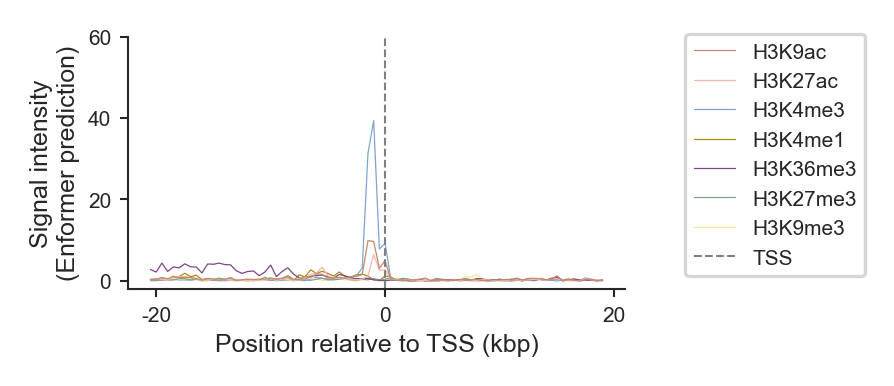

In [12]:
legend_order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# tracks = np.load('extra/datasets/processed/v1/E003_enformer/ENSG00000155660.npy') # (80, 7)
tracks = np.load('extra/datasets/processed/v1/E003/regions/ENSG00000155660.npy')[:7].T # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F.eps'

plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,legend=True,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
3521  ENSGRND00003522        0.802672        0.996431


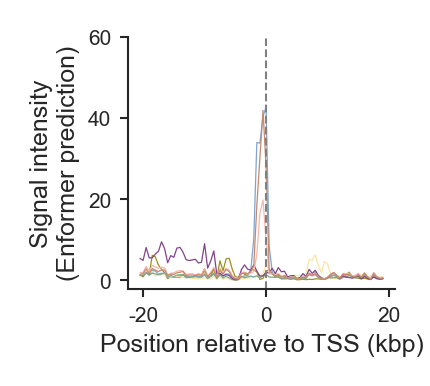

In [190]:
simulation_id = 'ENSGRND00003522'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
# tracks = np.log1p(tracks)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_1.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)


       simulation_id  bs_label_score  bf_label_score
883  ENSGRND00000884        0.448213        0.932168


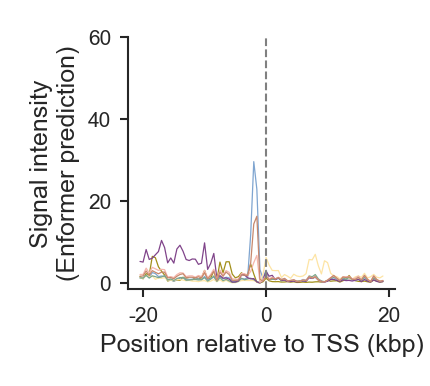

In [191]:

simulation_id = 'ENSGRND00000884'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_2.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
7299  ENSGRND00007300        0.568411        0.465244


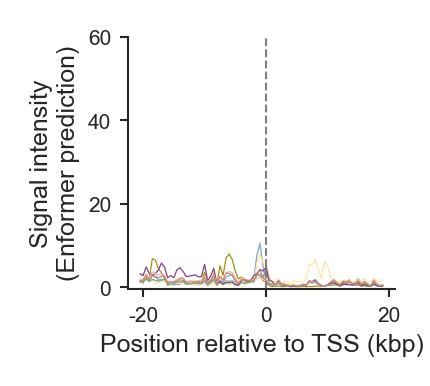

In [192]:
simulation_id = 'ENSGRND00007300'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_3.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
1751  ENSGRND00001752        0.109931        0.195685


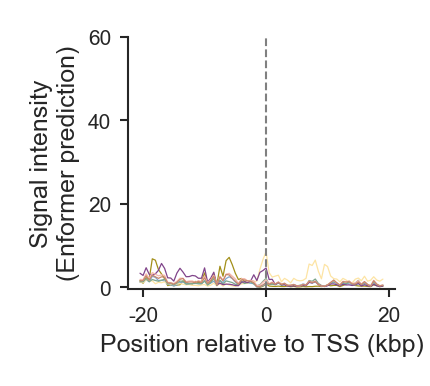

In [193]:
simulation_id = 'ENSGRND00001752'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_4.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()


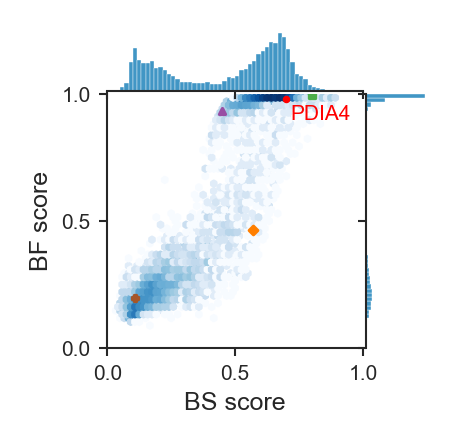

In [11]:
# g = sns.jointplot(
#     data=df,
#     x='bs_label_score', 
#     y='bf_label_score', 
#     kind='hex',
#     height=3.5/2.54,     # 主图高度（单位：英寸）
# )

# ——参数可微调——
GRIDSIZE = 60        # hex 单元更细，40~80 之间试
ALPHA_SCAT = 0.25    # 叠加散点透明度
N_SCAT = 2000        # 随机抽样叠加的散点数
BINS = 'log'         # 对数缩放，突出中低密度
CMAP = 'Blues'       # 也可试 'viridis'/'mako'

# 主图
g = sns.jointplot(
    data=df,
    x='bs_label_score', 
    y='bf_label_score', 
    kind='hex',
    height=3.5/2.54,
    space=0.05,
    ratio=4,
    joint_kws=dict(
        gridsize=GRIDSIZE,
        mincnt=1,
        bins=BINS,                 # 关键：对数计数
        extent=(0, 1, 0, 1),
        cmap=CMAP
    ),
    marginal_kws=dict(
        bins=60,                   # 边际直方图更细
        stat='density',
        binrange=(0, 1)
    ),
)


# 设置坐标轴
g.ax_joint.set_ylabel('BF score', fontsize=6)
g.ax_joint.set_xlabel('BS score', fontsize=6)
g.ax_joint.set_title('', fontsize=6, fontweight='regular', y=1.1)
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])


# 在 (0.67,0.92) 添加红色标记和注释
x0, y0 = 0.7, 0.98
g.ax_joint.scatter(x0, y0, color="red", s=1, zorder=5)  # 标红点
g.ax_joint.annotate(
    "PDIA4", 
    (x0, y0), 
    textcoords="offset points", 
    xytext=(1, -5),  # 注释位置相对偏移
    fontsize=5, 
    color="red"
)
g.ax_joint.set_xlim(0, 1.0)
g.ax_joint.set_ylim(0, 1.0)

def _get_loc(simulation_id):
    row = df[df['simulation_id'] == simulation_id]
    if row.empty:
        return None
    return row.iloc[0]['bs_label_score'], row.iloc[0]['bf_label_score']
# simulation_ids = ['ENSGRND00003522','ENSGRND00000884','ENSGRND00007300','ENSGRND00001752']
# for simulation_id in simulation_ids:
#     loc = _get_loc(simulation_id)
#     if loc:
#         x0, y0 = loc
#     g.ax_joint.scatter(x0, y0, color="red", s=0.5, zorder=5)  # 标红点


markers = ['o', '^', 's', 'D']   # 可根据需要扩展
markers = [ 's','^' , 'D', 'P', 'X', '*']
colors  = ["#4DAF4A",  # 绿
          "#984EA3",  # 紫
          "#FF7F00",  # 橙
          "#A65628",  # 棕
          "#F781BF",  # 粉
       ]

simulation_ids = ['ENSGRND00003522','ENSGRND00000884','ENSGRND00007300','ENSGRND00001752']



for idx, simulation_id in enumerate(simulation_ids):
    loc = _get_loc(simulation_id)
    if loc:
        x0, y0 = loc
        g.ax_joint.scatter(
            x0, y0, 
            color=colors[idx % len(markers)], 
            s=2,                     # 放大一点更清楚
            zorder=10, 
            marker=markers[idx % len(markers)]  # 不同点不同形状
        )
        # g.ax_joint.annotate(
        #     simulation_id, (x0, y0),
        #     textcoords="offset points",
        #     xytext=(2, 2),
        #     fontsize=5,
        #     color="red"
        # )

saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5G.eps'
# plt.savefig(saved_path, format='eps', bbox_inches='tight')

plt.show()

# Low expression

In [28]:
# df = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ENSG00000155660_random_center_replaced_100k.csv')
df = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/ENSG00000143340_random_center_replaced_100k.csv')
# df[(df['bf_label_score'] > 0.85) & (df['bs_label_score'] < 0.45)]
df['delta'] = df['bf_label_score'] - df['bs_label_score']
df.sort_values(by='delta', ascending=False, inplace=True)
# df.head(100)
print(df[df['delta'] < 0])

        simulation_id  bs_label_score  bf_label_score     delta
9869  ENSGRND00009870        0.428960        0.428952 -0.000008
6018  ENSGRND00006019        0.335237        0.335209 -0.000028
6494  ENSGRND00006495        0.270619        0.270574 -0.000045
3878  ENSGRND00003879        0.088233        0.088160 -0.000073
8047  ENSGRND00008048        0.658913        0.658822 -0.000091
...               ...             ...             ...       ...
4659  ENSGRND00004660        0.442460        0.097986 -0.344474
5578  ENSGRND00005579        0.446228        0.101530 -0.344697
6669  ENSGRND00006670        0.450261        0.104113 -0.346148
4397  ENSGRND00004398        0.450053        0.102334 -0.347719
3728  ENSGRND00003729        0.448075        0.099752 -0.348322

[5439 rows x 4 columns]


In [79]:
df[(df[f'bf_label_score'] < 0.4) & (df['bs_label_score'] > 0.55)]

,simulation_id,bs_label_score,bf_label_score,delta
118,ENSGRND00000119,0.554502,0.366393,-0.188109
2034,ENSGRND00002035,0.584061,0.395584,-0.188476
1600,ENSGRND00001601,0.559944,0.366042,-0.193902
7570,ENSGRND00007571,0.550592,0.354150,-0.196441
6524,ENSGRND00006525,0.554135,0.354210,-0.199926
1521,ENSGRND00001522,0.570624,0.369685,-0.200939
1157,ENSGRND00001158,0.559086,0.354007,-0.205079
3704,ENSGRND00003705,0.560595,0.354184,-0.206411
2645,ENSGRND00002646,0.574499,0.358137,-0.216363
8221,ENSGRND00008222,0.567560,0.335201,-0.232359


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()


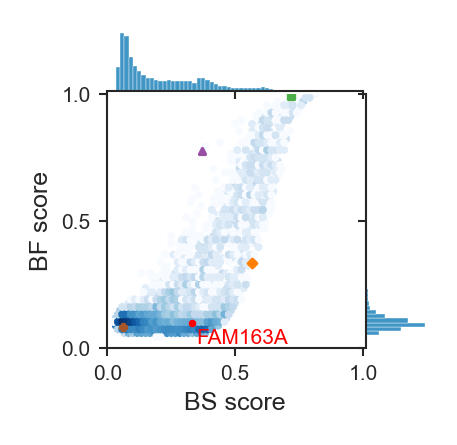

In [94]:
# g = sns.jointplot(
#     data=df,
#     x='bs_label_score', 
#     y='bf_label_score', 
#     kind='hex',
#     height=3.5/2.54,     # 主图高度（单位：英寸）
# )

# ——参数可微调——
GRIDSIZE = 60        # hex 单元更细，40~80 之间试
ALPHA_SCAT = 0.25    # 叠加散点透明度
N_SCAT = 2000        # 随机抽样叠加的散点数
BINS = 'log'         # 对数缩放，突出中低密度
CMAP = 'Blues'       # 也可试 'viridis'/'mako'

# 主图
g = sns.jointplot(
    data=df,
    x='bs_label_score', 
    y='bf_label_score', 
    kind='hex',
    height=3.5/2.54,
    space=0.05,
    ratio=4,
    joint_kws=dict(
        gridsize=GRIDSIZE,
        mincnt=1,
        bins=BINS,                 # 关键：对数计数
        extent=(0, 1, 0, 1),
        cmap=CMAP
    ),
    marginal_kws=dict(
        bins=60,                   # 边际直方图更细
        stat='density',
        binrange=(0, 1)
    ),
)


# 设置坐标轴
g.ax_joint.set_ylabel('BF score', fontsize=6)
g.ax_joint.set_xlabel('BS score', fontsize=6)
g.ax_joint.set_title('', fontsize=6, fontweight='regular', y=1.1)
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])


# 在 (0.67,0.92) 添加红色标记和注释
x0, y0 = 0.33339432, 0.09844328
g.ax_joint.scatter(x0, y0, color="red", s=1, zorder=5)  # 标红点
g.ax_joint.annotate(
    "FAM163A", 
    (x0, y0), 
    textcoords="offset points", 
    xytext=(1, -5),  # 注释位置相对偏移
    fontsize=5, 
    color="red"
)
g.ax_joint.set_xlim(0, 1.0)
g.ax_joint.set_ylim(0, 1.0)

def _get_loc(simulation_id):
    row = df[df['simulation_id'] == simulation_id]
    if row.empty:
        return None
    return row.iloc[0]['bs_label_score'], row.iloc[0]['bf_label_score']
# simulation_ids = ['ENSGRND00003522','ENSGRND00000884','ENSGRND00007300','ENSGRND00001752']
# for simulation_id in simulation_ids:
#     loc = _get_loc(simulation_id)
#     if loc:
#         x0, y0 = loc
#     g.ax_joint.scatter(x0, y0, color="red", s=0.5, zorder=5)  # 标红点


markers = ['o', '^', 's', 'D']   # 可根据需要扩展
markers = [ 's','^' , 'D', 'P', 'X', '*']
colors  = ["#4DAF4A",  # 绿
          "#984EA3",  # 紫
          "#FF7F00",  # 橙
          "#A65628",  # 棕
          "#F781BF",  # 粉
       ]

simulation_ids = ['ENSGRND00009765','ENSGRND00007303','ENSGRND00008222','ENSGRND00001752']



for idx, simulation_id in enumerate(simulation_ids):
    loc = _get_loc(simulation_id)
    if loc:
        x0, y0 = loc
        g.ax_joint.scatter(
            x0, y0, 
            color=colors[idx % len(markers)], 
            s=2,                     # 放大一点更清楚
            zorder=10, 
            marker=markers[idx % len(markers)]  # 不同点不同形状
        )
        # g.ax_joint.annotate(
        #     simulation_id, (x0, y0),
        #     textcoords="offset points",
        #     xytext=(2, 2),
        #     fontsize=5,
        #     color="red"
        # )

saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5G.eps'
# plt.savefig(saved_path, format='eps', bbox_inches='tight')

plt.show()

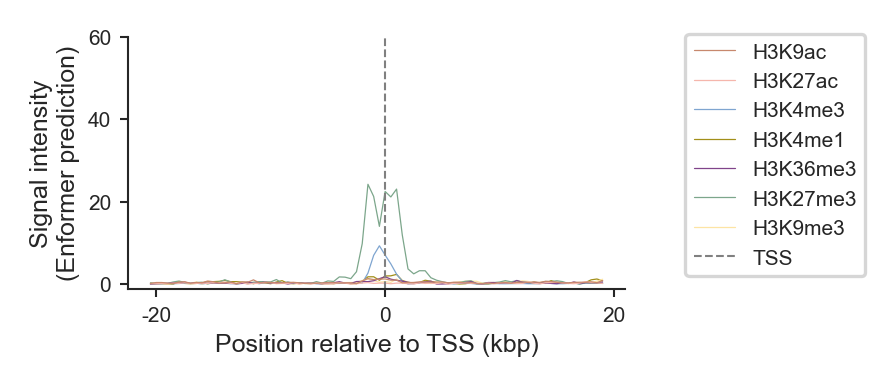

In [47]:
legend_order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# tracks = np.load('extra/datasets/processed/v1/E003_enformer/ENSG00000155660.npy') # (80, 7)
tracks = np.load('extra/datasets/processed/v1/E003/regions/ENSG00000143340.npy')[:7].T # (80, 7)
# saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F.eps'
saved_path = None

plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,legend=True,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score     delta
9764  ENSGRND00009765        0.717249        0.990392  0.273143


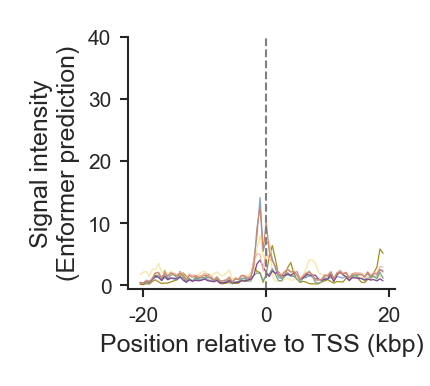

In [74]:
simulation_id = 'ENSGRND00009765'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
# tracks = np.log1p(tracks)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_1.eps'
figsize = (4/2.54, 3.5/2.54)
saved_path = None

plot_tracks(tracks,ylim=40,color_map=color_map,figsize=figsize,legend=False,saved_path=saved_path)


        simulation_id  bs_label_score  bf_label_score     delta
7302  ENSGRND00007303        0.369622         0.77412  0.404498


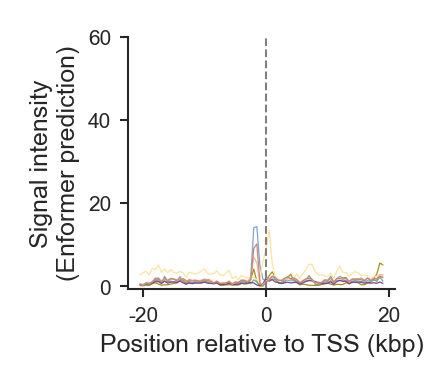

In [61]:

simulation_id = 'ENSGRND00007303'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_2.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score     delta
8221  ENSGRND00008222         0.56756        0.335201 -0.232359


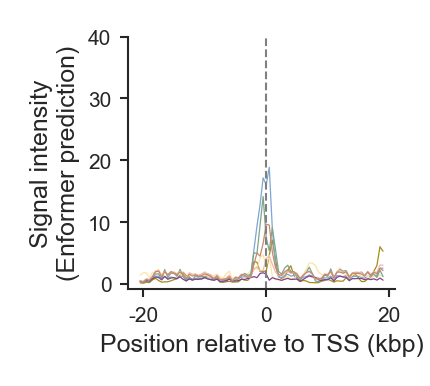

In [89]:
simulation_id = 'ENSGRND00008222'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_3.eps'
figsize = (4/2.54, 3.5/2.54)
saved_path = None
plot_tracks(tracks,ylim=40,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score     delta
1751  ENSGRND00001752        0.060681         0.08161  0.020929


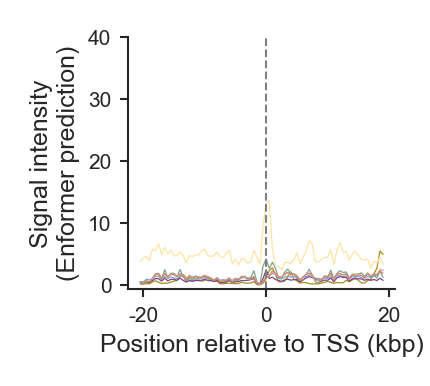

In [72]:
simulation_id = 'ENSGRND00001752'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/datasets/benchmark/Promoterformer/figures/v6/Figure5F_4.eps'
figsize = (4/2.54, 3.5/2.54)
saved_path = None
plot_tracks(tracks,ylim=40,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

# Evaluation of mean and noise

In [3]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False

remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['mean_label']
gene_id = "ENSG00000155660"
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.mean_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = BurstPrisma(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [22]:
# gene_id = 'ENSG00000155660'
# gene_id = 'ENSG00000143340'
strand = '+' # '+', '-' Enformer 预测的所有序列都是正链的
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k_mean.csv', index=False)


100%|██████████| 10000/10000 [00:42<00:00, 237.03it/s]


In [17]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  BurstPrisma
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "benchmark/Promoterformer/configs/default.yaml"
config = get_config(config_path)
add_feature_bin = False

remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['cv_label']
gene_id = "ENSG00000155660"
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"benchmark/Promoterformer/checkpoints/{eid}.{fold}.cv_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = BurstPrisma(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [18]:
# gene_id = 'ENSG00000155660'
# gene_id = 'ENSG00000143340'
strand = '+' # '+', '-' Enformer 预测的所有序列都是正链的
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k_cv.csv', index=False)


100%|██████████| 10000/10000 [00:43<00:00, 228.95it/s]


In [34]:
mean_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k_mean.csv')
noise_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k_cv.csv')
bs_bf_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/{gene_id}_random_center_replaced_100k.csv')
df = pd.merge(mean_predictions, noise_predictions, on='simulation_id')
df = pd.merge(df, bs_bf_predictions, on='simulation_id')
df[['bs_label_score','bf_label_score','mean_label_score','cv_label_score']].corr()  


,bs_label_score,bf_label_score,mean_label_score,cv_label_score
bs_label_score,1.000000,0.941470,0.864996,-0.145065
bf_label_score,0.941470,1.000000,0.913436,-0.130318
mean_label_score,0.864996,0.913436,1.000000,-0.131923
cv_label_score,-0.145065,-0.130318,-0.131923,1.000000


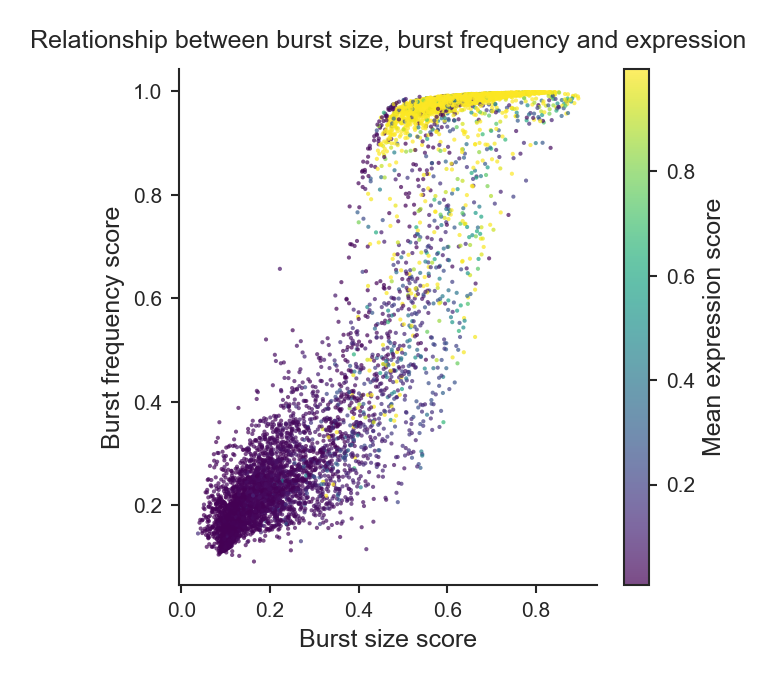

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设 df 已加载并包含 bs_label_score, bf_label_score, mean_label_score 三列
plt.figure(figsize=(6/2.54, 6/2.54))  # 图像尺寸（厘米）

# 绘制散点图
sc = plt.scatter(
    data=df,
    x='bs_label_score',
    y='bf_label_score',
    c=df['mean_label_score'],  # 颜色取自 mean_label_score
    cmap='viridis',            # 可改为 "coolwarm" 或 "plasma"
    s=1,                      # 点大小
    alpha=0.7,                 # 透明度 
    linewidths=0
)

# 添加颜色条
cb = plt.colorbar(sc)
cb.set_label('Mean expression score',)
cb.ax.tick_params()

# 坐标轴美化
plt.xlabel('Burst size score')
plt.ylabel('Burst frequency score')

plt.title('Relationship between burst size, burst frequency and expression', pad=5)

plt.tight_layout()
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4_Scatter.eps', format='eps', bbox_inches='tight')
plt.show()

mean_bin
(-0.001, 0.1]    3913
(0.1, 0.2]        328
(0.2, 0.3]        198
(0.3, 0.4]        123
(0.4, 0.5]         70
(0.5, 0.6]         60
(0.6, 0.7]         40
(0.7, 0.8]         42
(0.8, 0.9]         52
(0.9, 1.0]       5174
Name: count, dtype: int64


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_90478/875793063.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


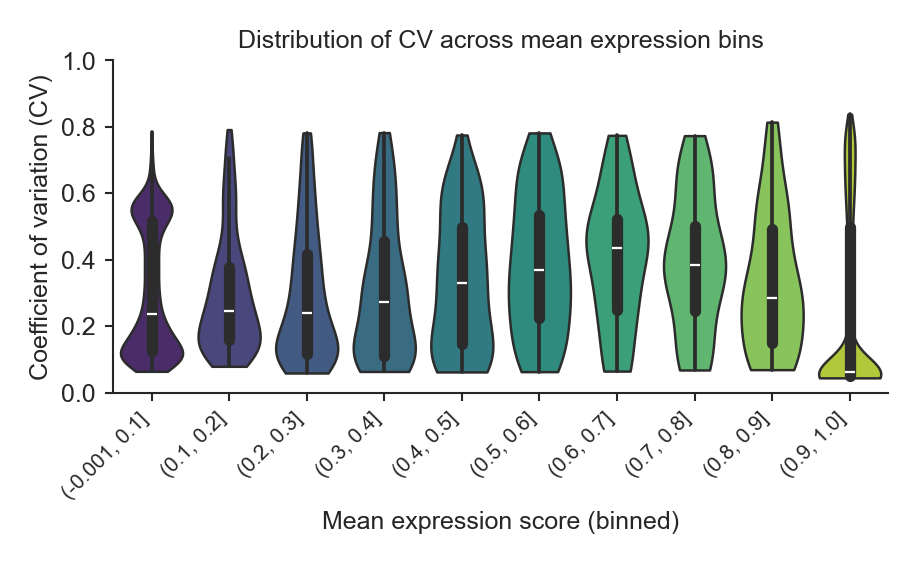

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 假设 df 已加载，包含 mean_label_score 与 cv_label_score
# 将 mean_label_score 分为 10 个等宽区间
df['mean_bin'] = pd.cut(df['mean_label_score'], bins=np.linspace(0, 1, 11), include_lowest=True)

# 查看每个分组的样本数（可选）
print(df['mean_bin'].value_counts().sort_index())



# === 可视化1：小提琴图（更平滑展示分布）===
plt.figure(figsize=(8/2.54, 5/2.54))
sns.violinplot(
    data=df,
    x='mean_bin',
    y='cv_label_score',
    palette='viridis',
    # inner='box',
    linewidth=0.6,
    cut=0
)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=6)
plt.ylim(0, 1)
plt.xlabel('Mean expression score (binned)',)
plt.ylabel('Coefficient of variation (CV)')
plt.title('Distribution of CV across mean expression bins', pad=3)
plt.tight_layout()
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4_CV_violin.eps', format='eps', bbox_inches='tight')
plt.show()

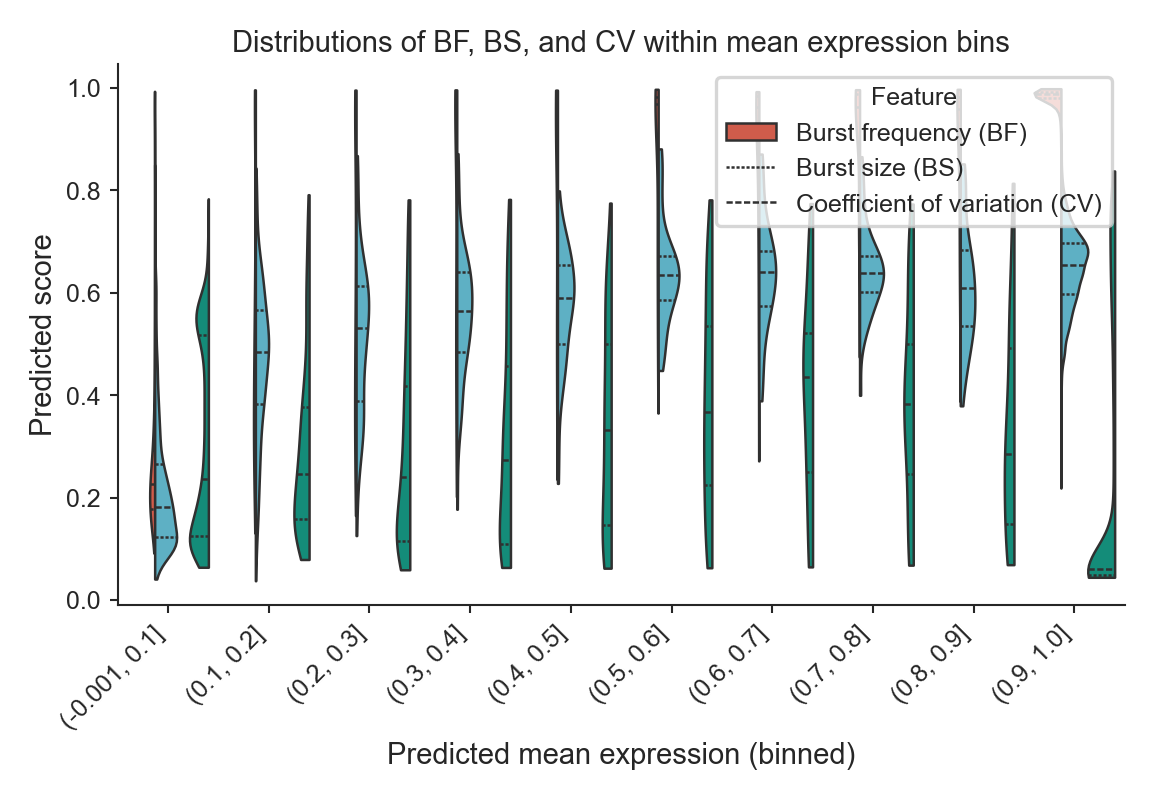

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ 将 mean_label_score 分箱
df['mean_bin'] = pd.cut(df['mean_label_score'], bins=np.linspace(0, 1, 11), include_lowest=True)

# 2️⃣ 将数据展开为“长格式”，方便绘图
df_melt = df.melt(
    id_vars=['mean_bin'],
    value_vars=['bf_label_score', 'bs_label_score', 'cv_label_score'],
    var_name='Burst_feature',
    value_name='Score'
)

# 3️⃣ 画出每个 mean bin 内，三个特征的分布
plt.figure(figsize=(10/2.54, 7/2.54))
sns.violinplot(
    data=df_melt,
    x='mean_bin',
    y='Score',
    hue='Burst_feature',
    split=True,
    inner='quartile',
    palette=['#E64B35', '#4DBBD5', '#00A087'],  # 红(BF), 蓝(BS), 绿(CV)
    linewidth=0.6,
    cut=0
)

# 坐标轴与标题
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
plt.xlabel('Predicted mean expression (binned)', fontsize=7)
plt.ylabel('Predicted score', fontsize=7)
plt.legend(
    title='Feature',
    labels=['Burst frequency (BF)', 'Burst size (BS)', 'Coefficient of variation (CV)'],
    fontsize=6,
    title_fontsize=6,
    loc='upper right'
)
plt.title('Distributions of BF, BS, and CV within mean expression bins', fontsize=7, pad=3)

plt.tight_layout()
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4_CV_BF_BS_bins.eps',
            # format='eps', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_76893/607474011.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_label, sub in df.groupby('bs_bin'):


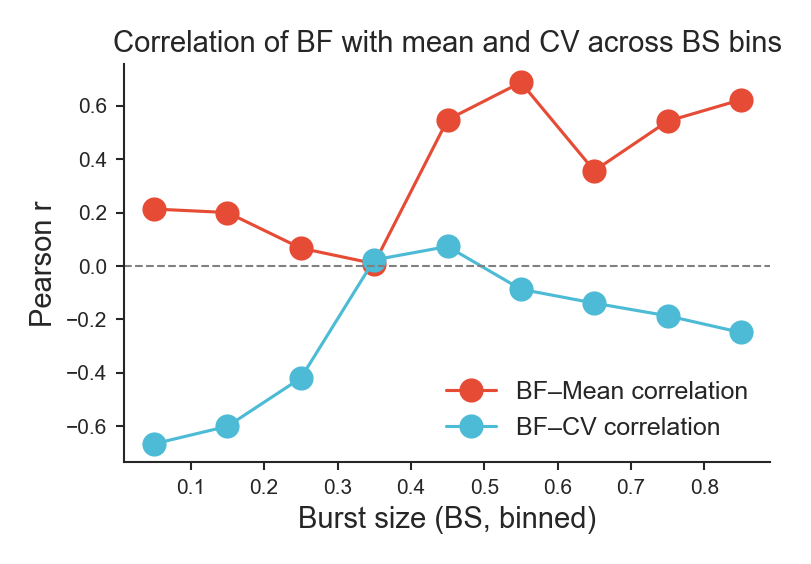

,bs_bin,bs_center,r_bf_mean,r_bf_cv,n
0,"(-0.001, 0.1]",0.0495,0.213264,-0.666843,415
1,"(0.1, 0.2]",0.1500,0.200125,-0.600697,1825
2,"(0.2, 0.3]",0.2500,0.066625,-0.420180,958
3,"(0.3, 0.4]",0.3500,0.008824,0.022650,507
4,"(0.4, 0.5]",0.4500,0.547767,0.072895,561
5,"(0.5, 0.6]",0.5500,0.687618,-0.087325,1506
6,"(0.6, 0.7]",0.6500,0.356680,-0.139343,2908
7,"(0.7, 0.8]",0.7500,0.542402,-0.186874,1203
8,"(0.8, 0.9]",0.8500,0.622767,-0.249337,117


In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 假设 df 包含以下列：
# ['bf_label_score', 'bs_label_score', 'mean_label_score', 'cv_label_score']

# 1️⃣ 将 BS 分为10个等宽 bin
df['bs_bin'] = pd.cut(df['bs_label_score'], bins=np.linspace(0, 1, 11), include_lowest=True)

# 2️⃣ 在每个 bin 内计算 BF 与 mean/CV 的 Pearson 相关
corr_results = []
for bin_label, sub in df.groupby('bs_bin'):
    if len(sub) < 10:  # 样本太少跳过
        continue
    r_bf_mean, _ = pearsonr(sub['bf_label_score'], sub['mean_label_score'])
    r_bf_cv, _   = pearsonr(sub['bf_label_score'], sub['cv_label_score'])
    corr_results.append({
        'bs_bin': str(bin_label),
        'bs_center': bin_label.mid,
        'r_bf_mean': r_bf_mean,
        'r_bf_cv': r_bf_cv,
        'n': len(sub)
    })

corr_df = pd.DataFrame(corr_results)

# 3️⃣ 绘制 BF–mean 与 BF–CV 的相关趋势
plt.figure(figsize=(7/2.54, 5/2.54))
plt.plot(corr_df['bs_center'], corr_df['r_bf_mean'], '-o', color='#E64B35', label='BF–Mean correlation')
plt.plot(corr_df['bs_center'], corr_df['r_bf_cv'], '-o', color='#4DBBD5', label='BF–CV correlation')

plt.axhline(0, color='gray', lw=0.5, ls='--')
plt.xlabel('Burst size (BS, binned)', fontsize=7)
plt.ylabel('Pearson r', fontsize=7)
plt.legend(frameon=False, fontsize=6)
plt.title('Correlation of BF with mean and CV across BS bins', fontsize=7, pad=3)
plt.tight_layout()
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4_BF_mean_cv_across_BSbins.eps',
#             format='eps', bbox_inches='tight')
plt.show()

corr_df

In [3]:



mean_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/predictions_mean.csv')[['eid','gene_id','mean_label_score']].rename(columns={'gene_id':'simulation_id'})
noise_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/predictions_cv.csv')[['eid','gene_id','cv_label_score']].rename(columns={"gene_id":'simulation_id'})
bs_bf_predictions = pd.read_csv(f'extra/datasets/benchmark/Promoterformer/results/predictions_bs_bf.csv')[['eid','gene_id','bs_label_score','bf_label_score']].rename(columns={"gene_id":'simulation_id'})
df = pd.merge(mean_predictions, noise_predictions, on=['simulation_id','eid'])
df = pd.merge(df, bs_bf_predictions, on=['simulation_id','eid'])
df[['bs_label_score','bf_label_score','mean_label_score','cv_label_score']].corr()  

,bs_label_score,bf_label_score,mean_label_score,cv_label_score
bs_label_score,1.000000,0.781118,0.794478,-0.126600
bf_label_score,0.781118,1.000000,0.976818,-0.375727
mean_label_score,0.794478,0.976818,1.000000,-0.370232
cv_label_score,-0.126600,-0.375727,-0.370232,1.000000


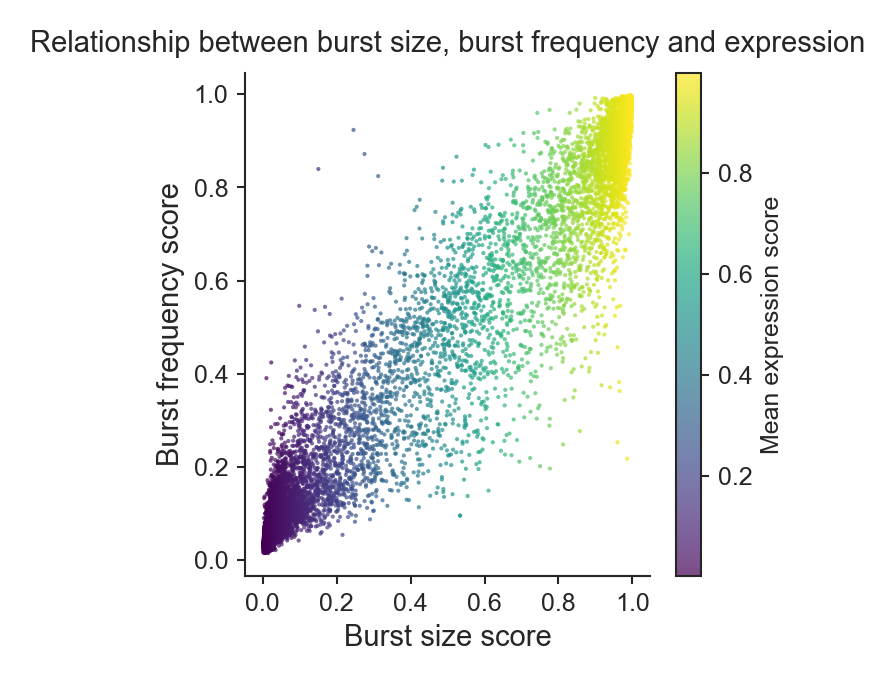

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设 df 已加载并包含 bs_label_score, bf_label_score, mean_label_score 三列
plt.figure(figsize=(6/2.54, 6/2.54))  # 图像尺寸（厘米）

# 绘制散点图
sc = plt.scatter(
    data=df[df['eid']=='E003'],
    x='mean_label_score',
    y='bf_label_score',
    c=df[df['eid']=='E003']['mean_label_score'],  # 颜色取自 mean_label_score
    cmap='viridis',            # 可改为 "coolwarm" 或 "plasma"
    s=1,                      # 点大小
    alpha=0.7,                 # 透明度 
    linewidths=0
)

# 添加颜色条
cb = plt.colorbar(sc)
cb.set_label('Mean expression score', fontsize=6)
cb.ax.tick_params(labelsize=6)

# 坐标轴美化
plt.xlabel('Burst size score', fontsize=7)
plt.ylabel('Burst frequency score', fontsize=7)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title('Relationship between burst size, burst frequency and expression', fontsize=7, pad=5)

plt.tight_layout()
# plt.savefig('extra/datasets/benchmark/Promoterformer/figures/v6/Figure4_Scatter.eps', format='eps', bbox_inches='tight')
plt.show()